# ICEVs Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("ICEV_dataset.csv")

/var/folders/zh/znnjbxzs5hqbkljnm3f8zf9w0000gn/T/ipykernel_12207/3200027280.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ICEV_dataset.csv")


In [ ]:
df

,Unnamed: 0,vehid,trip,timestamp,speed_kmh,maf_gsec,rpm,absload,temp_degc,fuelrate_lhr,...,dow_sin,dow_cos,doy_sin,doy_cos,road_class,displacement,stft_avg,ltft_avg,rho_air,encon
0,559,149,851,0,46.0,15.540000,2051.0,38.823528,3.345260,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,1.8,-3.90625,-7.03125,1.238535,0.982977
1,560,149,851,1100,48.0,25.530001,2215.0,38.823528,3.345260,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,1.8,-3.90625,-7.03125,1.238535,1.614890
2,561,149,851,1400,48.0,25.530001,2215.0,65.098038,3.345260,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,1.8,-3.90625,-7.03125,1.238535,1.614890
3,562,149,851,1800,48.0,25.530001,2215.0,65.098038,3.345260,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,1.8,-3.90625,-7.03125,1.238535,1.614890
4,563,149,851,2100,49.0,25.530001,2215.0,65.098038,3.345260,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,1.8,-3.90625,-7.03125,1.238535,1.614890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13129558,22436803,609,590,309300,51.0,16.600000,1343.0,NaN,27.358999,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,0.00000,-3.90625,1.139563,1.132923
13129559,22436804,609,590,311400,52.0,16.629999,1309.0,NaN,27.358999,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,0.00000,-3.90625,1.139563,1.134971
13129560,22436805,609,590,312100,52.0,16.629999,1309.0,NaN,27.358999,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,0.00000,-3.90625,1.139563,1.134971
13129561,22436806,609,590,312800,53.0,16.629999,1309.0,NaN,27.358999,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,2.34375,-3.90625,1.139563,1.162653


In [ ]:
fcr_null = df[df['encon'].isnull()]

In [ ]:
# 1. Count of unique cars (vehid) with null values per vehicle type
cars_per_type = fcr_null.groupby('vehicle_type')['vehid'].nunique()

# 2. Count of unique trips with null values per vehicle type
trips_per_type = fcr_null.groupby('vehicle_type')['trip'].nunique()

# 3. Average and total null timestamps per trip, grouped by vehicle type
# We group by vehicle_type and trip first to see the density of nulls
nulls_per_trip = fcr_null.groupby(['vehicle_type', 'trip']).size().reset_index(name='null_timestamp_count')

# Summarize the trip-level frequency
frequency_summary = nulls_per_trip.groupby('vehicle_type')['null_timestamp_count'].agg(['mean', 'max', 'sum']).rename(columns={
    'mean': 'Avg Nulls per Trip',
    'max': 'Max Nulls in a Single Trip',
    'sum': 'Total Null Timestamps'
})

# Combine everything into one report
report = pd.DataFrame({
    'Unique Cars': cars_per_type,
    'Total Trips with Nulls': trips_per_type
}).join(frequency_summary)

print("Analysis of Null FCR Values")
report

Analysis of Null FCR Values


,Unique Cars,Total Trips with Nulls,Avg Nulls per Trip,Max Nulls in a Single Trip,Total Null Timestamps
vehicle_type,,,,,
ICE,21,1068,595.945693,2782,636470


In [ ]:
# 5 minutes in milliseconds (assuming 'timestamp' is in ms)
five_min_ms = 5 * 60 * 1000

# 1. Determine trip boundaries for all trips
# We use the main 'df' to ensure we know the true start and end of every trip
trip_bounds = df.groupby(['vehid', 'trip'])['timestamp'].agg(['min', 'max']).reset_index()
trip_bounds.columns = ['vehid', 'trip', 'trip_start', 'trip_end']

# 2. Identify the rows with null values
target_col = 'encon'
null_data = df[df[target_col].isnull()].copy()

# 3. Merge trip boundaries to the null data
null_data = null_data.merge(trip_bounds, on=['vehid', 'trip'], how='left')

# 4. Calculate relative position
null_data['ms_from_start'] = null_data['timestamp'] - null_data['trip_start']
null_data['ms_to_end'] = null_data['trip_end'] - null_data['timestamp']

# 5. Categorize the timing
def categorize_position(row):
    if row['ms_from_start'] <= five_min_ms:
        return 'First 5 Minutes'
    elif row['ms_to_end'] <= five_min_ms:
        return 'Last 5 Minutes'
    else:
        return 'Middle'

null_data['trip_position'] = null_data.apply(categorize_position, axis=1)

# 6. Display Summary
summary = null_data.groupby(['vehicle_type', 'trip_position']).size().unstack(fill_value=0)
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

print("--- Distribution of Null FCR Values ---")
print("\nCounts:")
print(summary)
print("\nPercentages (%):")
print(summary_pct.round(2))

--- Distribution of Null FCR Values ---

Counts:
trip_position  First 5 Minutes  Last 5 Minutes  Middle
vehicle_type                                          
ICE                     323434          181083  131953

Percentages (%):
trip_position  First 5 Minutes  Last 5 Minutes  Middle
vehicle_type                                          
ICE                      50.82           28.45   20.73


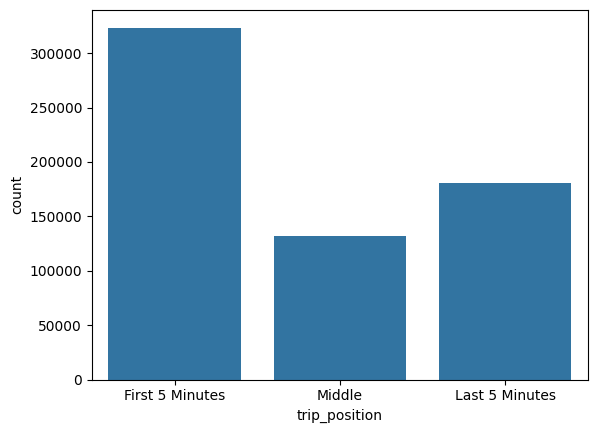

In [ ]:
# Ensure the categories are ordered logically for the charts
order = ['First 5 Minutes', 'Middle', 'Last 5 Minutes']

sns.countplot(
    data=null_data,
    x='trip_position',
    order=order)
plt.show()

Since nulls are concentrated at the beginning of trips, simply filling them with a global mean would be a mistake. A "Cold Start" (the first few minutes of driving) has a much higher fuel consumption rate than a warm engine.

In [ ]:
total_trips = df.groupby('vehid')['trip'].nunique().sum()
print(f"Total Number of Unique Trips: {total_trips}")

Total Number of Unique Trips: 18936


/var/folders/zh/znnjbxzs5hqbkljnm3f8zf9w0000gn/T/ipykernel_12207/1587994014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='road_class', palette='viridis')


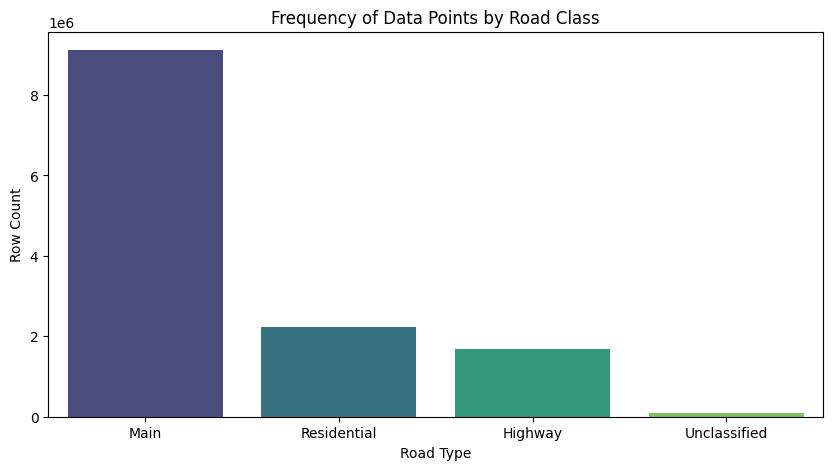

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='road_class', palette='viridis')
plt.title('Frequency of Data Points by Road Class')
plt.xlabel('Road Type')
plt.ylabel('Row Count')
plt.show()

In [ ]:
trip_duration = df.groupby(['vehid', 'trip'])['timestamp'].agg(lambda x: (x.max() - x.min()) / 60000)

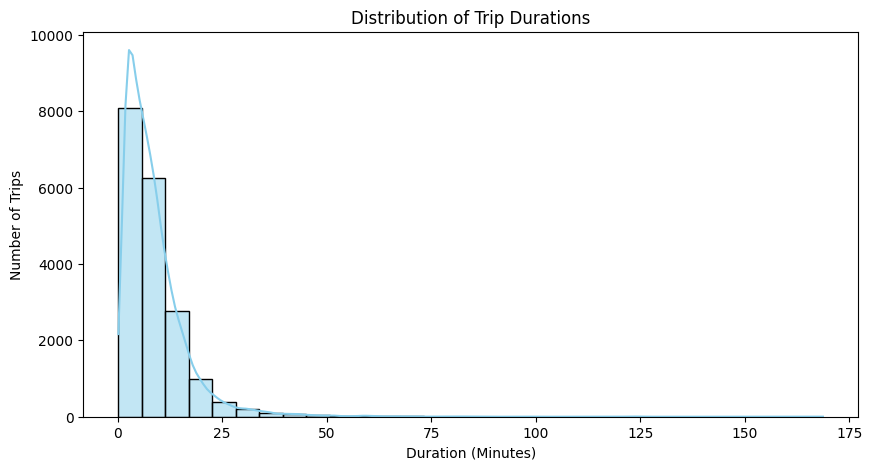

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(trip_duration, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Trip Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Trips')
plt.show()

In [ ]:
road_summary = df.groupby(['vehid', 'trip'])['road_class'].agg(lambda x: x.value_counts().index[0]).value_counts()
print("\nPrimary Road Type per Trip:")
print(road_summary)


Primary Road Type per Trip:
road_class
Main            14795
Highway          2561
Residential      1564
Unclassified       16
Name: count, dtype: int64


In [ ]:
trip_stats = df.groupby(['vehid', 'trip'])['timestamp'].agg(lambda x: (x.max() - x.min()) / 60000).reset_index()
trip_stats.columns = ['vehid', 'trip', 'duration_min']
bins = [0, 10, 20, 30, 50, float('inf')]
labels = ['<10 min', '10-20 min', '20-30 min', '30-50 min', '>50 min']
trip_stats['duration_category'] = pd.cut(trip_stats['duration_min'], bins=bins, labels=labels, right=False)

In [ ]:
df_comparison = df.merge(trip_stats[['vehid', 'trip', 'duration_category']], on=['vehid', 'trip'], how='left')

/var/folders/zh/znnjbxzs5hqbkljnm3f8zf9w0000gn/T/ipykernel_12207/1846595942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_comparison, x='duration_category', y='encon', palette='tab10', showfliers=False)


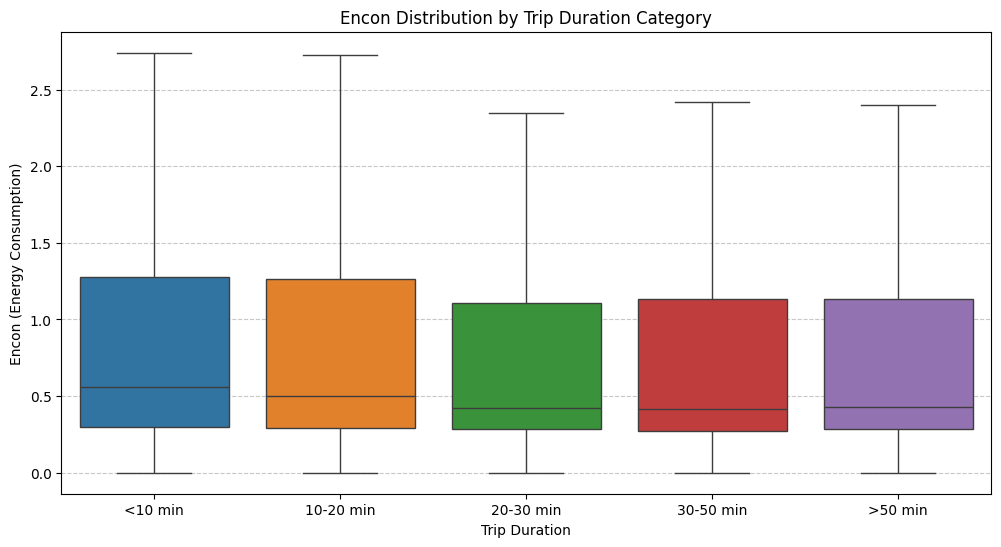

In [ ]:
plt.figure(figsize=(12, 6))
# Using showfliers=False to keep the focus on the bulk of the distribution (IQR)
sns.boxplot(data=df_comparison, x='duration_category', y='encon', palette='tab10', showfliers=False)

plt.title('Encon Distribution by Trip Duration Category')
plt.xlabel('Trip Duration')
plt.ylabel('Encon (Energy Consumption)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

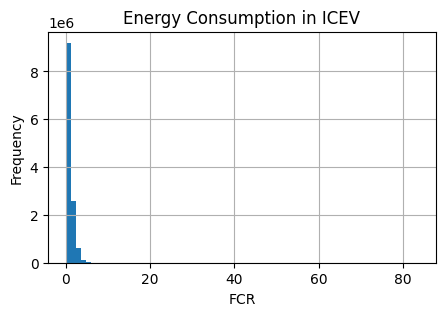

In [ ]:
plt.figure(figsize = (5,3))
df["encon"].hist(bins=70)
plt.title("Energy Consumption in ICEV")
plt.xlabel("FCR")
plt.ylabel("Frequency")
plt.show()

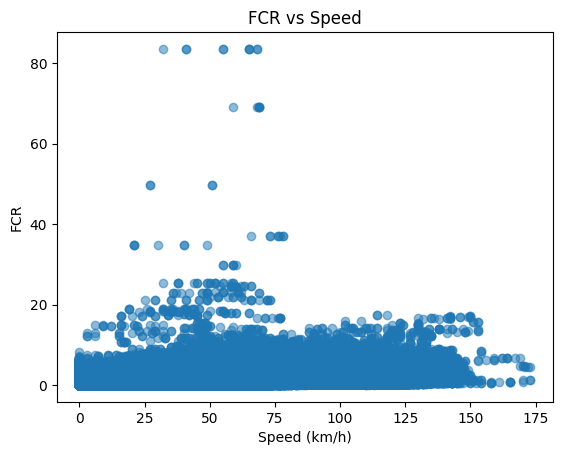

In [ ]:
plt.scatter(df["speed_kmh"], df["encon"], alpha=0.5)
plt.xlabel("Speed (km/h)")
plt.ylabel("FCR")
plt.title("FCR vs Speed")
plt.show()

In [ ]:
df.columns

Index(['Unnamed: 0', 'vehid', 'trip', 'timestamp', 'speed_kmh', 'maf_gsec',
       'rpm', 'absload', 'temp_degc', 'fuelrate_lhr', 'ac_kw', 'ac_watts',
       'heater_watts', 'hv_battery_current', 'hv_battery_soc',
       'hv_battery_voltage', 'stft_bank1', 'stft_bank2', 'ltft_bank1',
       'ltft_bank2', 'vehicle_class', 'engine_config', 'transmission',
       'drive_wheels', 'generalized_weight', 'vehicle_type', 'hour',
       'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'road_class',
       'displacement', 'stft_avg', 'ltft_avg', 'rho_air', 'encon'],
      dtype='object')

In [ ]:
df = df.drop(columns={'Unnamed: 0'})

In [ ]:
df[['drive_wheels']]

,drive_wheels
0,NO DATA
1,NO DATA
2,NO DATA
3,NO DATA
4,NO DATA
...,...
13129558,NO DATA
13129559,NO DATA
13129560,NO DATA
13129561,NO DATA


In [ ]:
df[['vehicle_class', 'engine_config']]

,vehicle_class,engine_config
0,NO DATA,4-FI 1.8L
1,NO DATA,4-FI 1.8L
2,NO DATA,4-FI 1.8L
3,NO DATA,4-FI 1.8L
4,NO DATA,4-FI 1.8L
...,...,...
13129558,NO DATA,V6 3.8L
13129559,NO DATA,V6 3.8L
13129560,NO DATA,V6 3.8L
13129561,NO DATA,V6 3.8L


In [ ]:
df.engine_config.unique()

array(['4-FI 1.8L', '4-FI 2.2L', '4-FI 1.6L', '6-FI 2.7L', '4-FI 2.4L',
       '4-FI 2.5L', '4-FI 2.0L', '4-FI 1.5L', '4-FI 1.6L T/C',
       '6-FI 3.5L', '6-FI 3.7L', '5-FI 2.5L', '3.0L 6cyl 4A', 'V6 3.1L',
       'V6 3.0L', '6-FI 4.3L', '5-FI 2.5L PZEV', '4-FI T/C 1.4L',
       '6-FI 3.0L', '4-FI 2.3L ULEV', '6-FI 3.6L', '6-FI 3.8L',
       '4-FI 2.0L PZEV', '4-FI S/C 1.8L GAS', '2.4L', '4-FI 2.0L T/C',
       '8-FI 4.8L', '6-FI 4.2L', '6-EFI 3.0L', '4-FI T/C 2.0L',
       '6-FI 3.3L', 'V6 4.0L', 'V8 4.7L', '8-FI 5.3L', '4-FI 2.3L T/C',
       '8-FI 5.4L', '6-EFI 4.2L ', 'H-4 2.0 L/122', 'V6 3.8L',
       '4-FI 2.3L', 'I4 2.4L Flex Fuel', '6-FI 3.4L', '8-FI 4.6L',
       '6-FI 3.1L', '6-242-MFI 4.0L', '4-FI 1.4L T/C',
       '8-FI 5.7L HEMI (Hemi engine)', '2.3L Gasoline I4',
       '4-FI 1.5L T/C', '8-FI 4.7L', '10-FI 6.8L', '8-FI 5.7L HEMI',
       '8-4V/FI 6.0L', 'I4 2.2L', '8-DSL 6.7L T/C', 'V6 3.5L',
       '8-EFI 5.0L', 'H-4 2.5L', 'I-4 1.8L', '8-FI 5.3L ', 'I-4 2.4L'],
      d

In [ ]:
len(df.vehid.unique())

264

In [ ]:
vehid = df[['vehid', 'engine_config', 'vehicle_class', 'displacement']].drop_duplicates()

In [ ]:
vehid[vehid.vehicle_class=='NO DATA']

,vehid,engine_config,vehicle_class,displacement
0,149,4-FI 1.8L,NO DATA,1.8
728,174,4-FI 2.2L,NO DATA,2.2
1027,180,4-FI 1.6L,NO DATA,1.6
1883,246,6-FI 2.7L,NO DATA,2.7
2372,248,4-FI 2.4L,NO DATA,2.4
...,...,...,...,...
10700739,625,I-4 1.8L,NO DATA,1.8
11251910,131,8-FI 5.3L,NO DATA,5.3
11965339,517,6-FI 3.5L,NO DATA,3.5
12173411,630,I-4 2.4L,NO DATA,2.4


In [ ]:
vehid[(vehid.vehicle_class=='NO DATA') & (vehid.displacement.isnull())]

,vehid,engine_config,vehicle_class,displacement
212725,597,H-4 2.0 L/122,NO DATA,NaN


In [ ]:
vehid.loc[vehid['vehid'] == 597, 'displacement'] = 2.0

In [ ]:
vehid[(vehid.displacement.isnull())]

,vehid,engine_config,vehicle_class,displacement


Only 4 out of 264 vehicles have vehicle class data ==> instead of using Sedan/SUV/..., we'll use "Engine Tier" alias as "vehicle_class."

| Engine Tier | Typical Displacements | Likely Vehicle Classes |
| :--- | :--- | :--- |
| **Small/Economy** | 0.6L - 2L (4-cyl) | Compact Sedans, Hatchbacks, Subcompact SUVs |
| **Medium** | 2.0L - 3.0L (4 or 6-cyl) | Mid-size Sedans, Crossovers, Small Pickups |
| **Large** | 3.0L - 3.7L |SUV/Large Sedans |
| **Heavy-Duty** | 3.8L - 8.4L (6, 8, or 10-cyl) | Full-size SUVs, Heavy-duty Trucks, Vans |

In [ ]:
df[df.displacement.isnull()][['displacement']]

,displacement
212725,NaN
212726,NaN
212727,NaN
212728,NaN
212729,NaN
...,...
13109168,NaN
13109169,NaN
13109170,NaN
13109171,NaN


In [ ]:
df.loc[df['vehid'] == 597, 'displacement'] = 2.0
def engine_to_class(liters):
    if pd.isna(liters):
        return 'Unknown'
    if liters >= 3.8:
        return 'Heavy'
    elif liters >= 3.0:
        return 'Large'
    elif liters >= 2.0:
        return 'Medium'
    elif liters > 0:
        return 'Small'

    return 'Unknown'

df['inferred_class'] = df['displacement'].apply(engine_to_class)

print(df[df['vehid'] == 597][['engine_config', 'displacement', 'inferred_class']].drop_duplicates())
print("\nClass Distribution:")
print(df['inferred_class'].value_counts())

        engine_config  displacement inferred_class
212725  H-4 2.0 L/122           2.0         Medium

Class Distribution:
inferred_class
Medium    6319798
Large     3636064
Small     2429511
Heavy      744190
Name: count, dtype: int64


/var/folders/zh/znnjbxzs5hqbkljnm3f8zf9w0000gn/T/ipykernel_12207/3297127096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='inferred_class', y='encon',


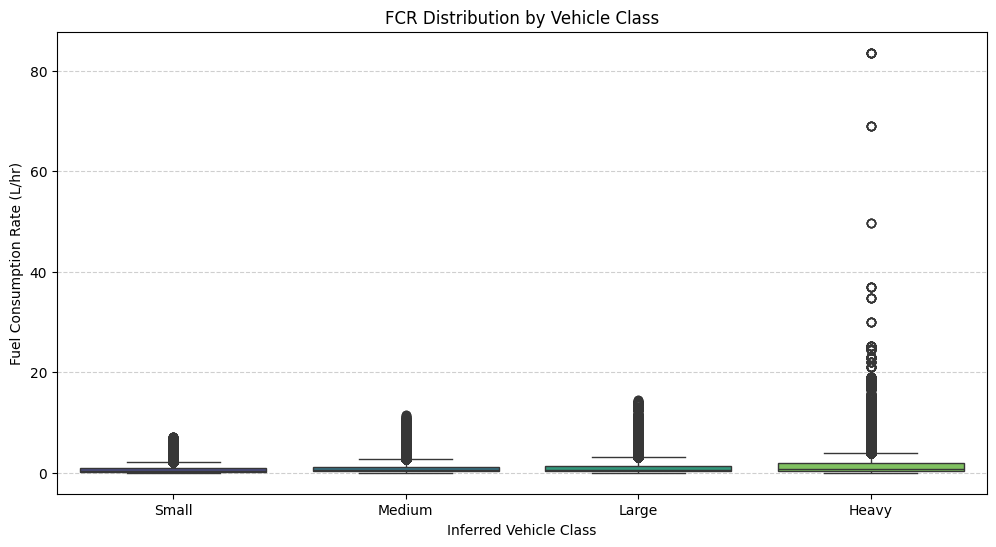

In [ ]:
class_order = ['Small', 'Medium', 'Large', 'Heavy']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='inferred_class', y='encon',
            order=class_order,
            palette='viridis')
plt.title('FCR Distribution by Vehicle Class')
plt.xlabel('Inferred Vehicle Class')
plt.ylabel('Fuel Consumption Rate (L/hr)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

/var/folders/zh/znnjbxzs5hqbkljnm3f8zf9w0000gn/T/ipykernel_12207/2115666859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='inferred_class', y='encon',


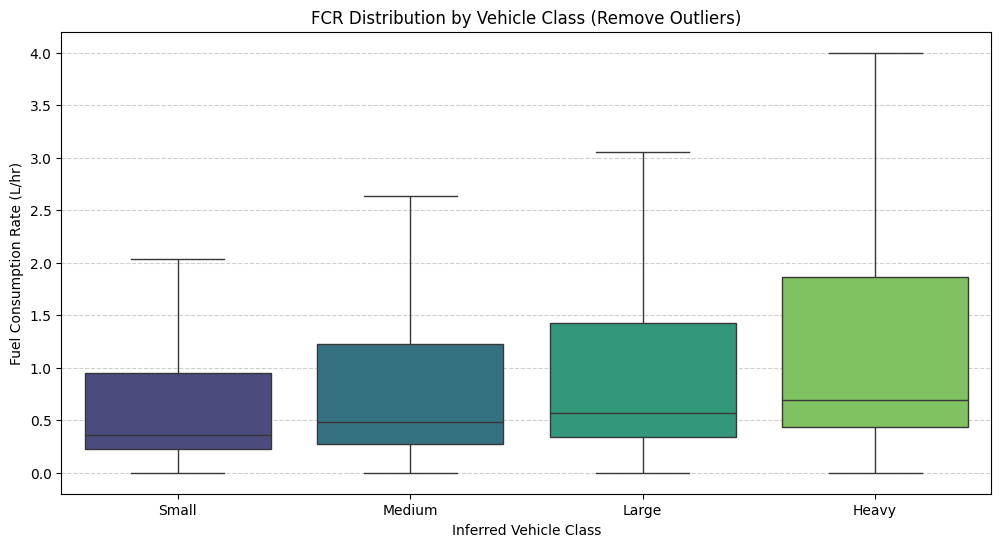

In [ ]:
class_order = ['Small', 'Medium', 'Large', 'Heavy']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='inferred_class', y='encon',
            order=class_order,
            palette='viridis',
           showfliers=False)
plt.title('FCR Distribution by Vehicle Class (Remove Outliers)')
plt.xlabel('Inferred Vehicle Class')
plt.ylabel('Fuel Consumption Rate (L/hr)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

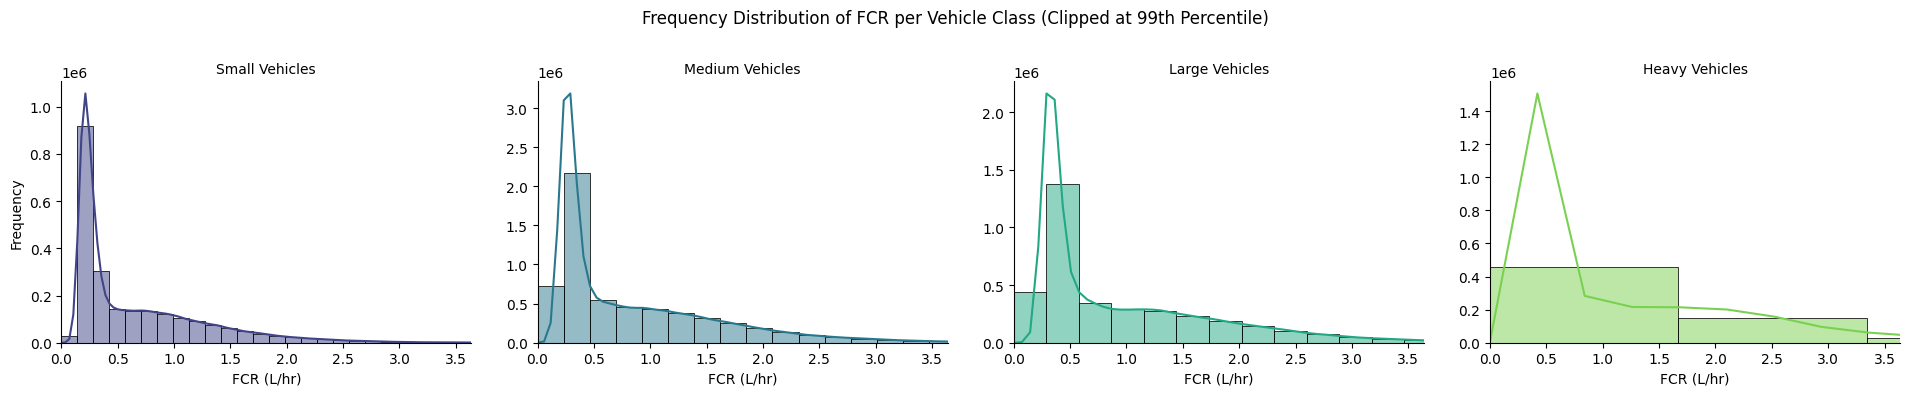

In [ ]:
upper_limit = df['encon'].quantile(0.99)

g = sns.FacetGrid(df, col="inferred_class",
                  col_order=class_order,
                  sharey=False,
                  height=4, aspect=1.2,
                  hue='inferred_class', palette='viridis')

g.map(sns.histplot, "encon", bins=50, kde=True)
g.set_axis_labels("FCR (L/hr)", "Frequency")
g.set_titles(template="{col_name} Vehicles")
for ax in g.axes.flat:
    ax.set_xlim(0, upper_limit)

plt.subplots_adjust(top=0.8)
g.fig.suptitle('Frequency Distribution of FCR per Vehicle Class (Clipped at 99th Percentile)')
plt.show()

In [ ]:
print("Mean FCR by Vehicle Class:")
print(df.groupby('inferred_class')['encon'].mean().reindex(class_order))

Mean FCR by Vehicle Class:
inferred_class
Small     0.654617
Medium    0.840683
Large     0.986359
Heavy     1.259029
Name: encon, dtype: float64


1. The "Heavy" Outlier Profile
In your boxplot [cell 65], the Heavy class shows a "long tail" of outliers reaching FCR values between 40 and 80 L/hr. While the median for this group sits roughly around 1.0–1.5 L/hr, the extreme outliers are nearly double the peak outliers seen in the "Small" class.

2. Primary Causes for These Outliers
Transient High-Load Events: The FCR vs. Speed scatter plots suggest these spikes occur most frequently during acceleration from 0 to 40 km/h. Moving a high-mass vehicle (like the 5000+ lb trucks in this category) requires a massive initial surge of fuel.

Cold Start Enrichment: Your "Cold Start" analysis [cell 8] confirms that the ICE category (which contains these heavy vehicles) sees a significant jump in both mean and standard deviation during the first 3 minutes of a trip. The engine control unit (ECU) runs a "rich" fuel mixture to warm up the catalytic converter, causing sustained high FCR even at low speeds.

Towing or Heavy Payload: The generalized_weight for this class goes up to 6500 lbs. Vehicles at the top end of this weight bracket encounter significantly more resistance, pushing the engine into high-load zones more frequently.

In [ ]:
df['elapsed_min'] = df.groupby(['vehid', 'trip'])['timestamp'].transform(lambda x: (x - x.min()) / 60000)

In [ ]:
bin_size = 5
max_time = 40
df['trip_stage_bin'] = (df['elapsed_min'] // bin_size) * bin_size

In [ ]:
def format_label(x):
    if x >= max_time:
        return f">{max_time} min"
    return f"{int(x)}-{int(x+bin_size)} min"

df['trip_stage'] = df['trip_stage_bin'].apply(format_label)

In [ ]:
stage_order = [format_label(i) for i in range(0, max_time, bin_size)] + [f">{max_time} min"]
df['trip_stage'] = pd.Categorical(df['trip_stage'], categories=stage_order, ordered=True)

/var/folders/zh/znnjbxzs5hqbkljnm3f8zf9w0000gn/T/ipykernel_12207/1665634205.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='trip_stage', y='encon',


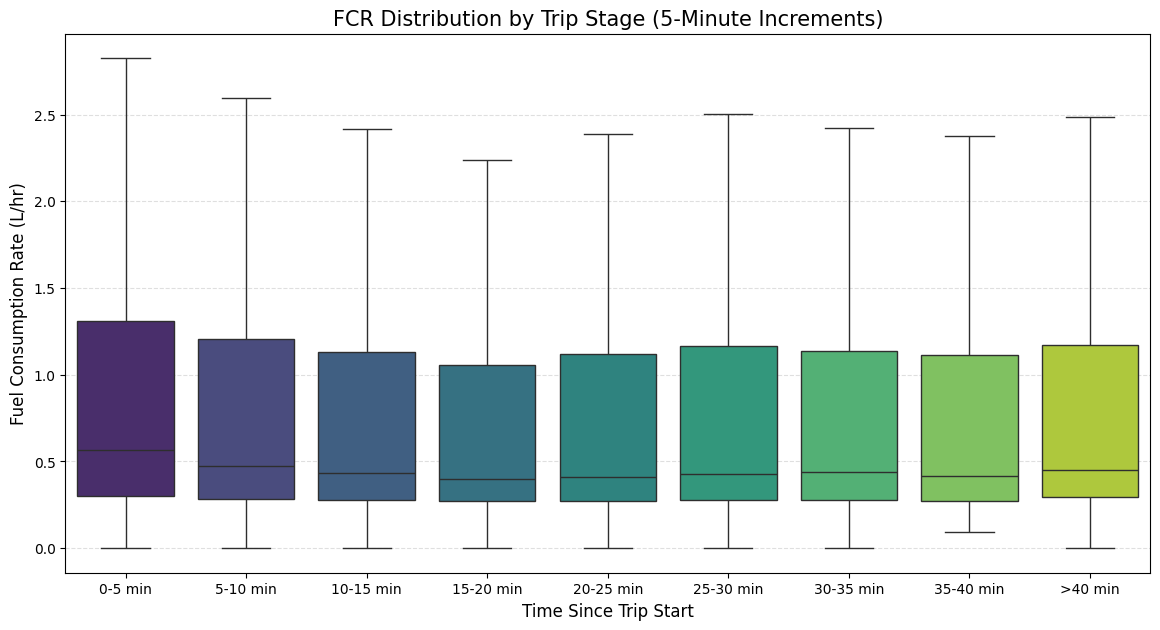

In [ ]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='trip_stage', y='encon',
            palette='viridis',
            showfliers=False)

plt.title('FCR Distribution by Trip Stage (5-Minute Increments)', fontsize=15)
plt.xlabel('Time Since Trip Start', fontsize=12)
plt.ylabel('Fuel Consumption Rate (L/hr)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


In [ ]:
stage_stats = df.groupby('trip_stage')['encon'].agg(['mean', 'median', 'std']).round(3)
print("FCR Statistics by Trip Stage:")
stage_stats

/var/folders/zh/znnjbxzs5hqbkljnm3f8zf9w0000gn/T/ipykernel_12207/293370496.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stage_stats = df.groupby('trip_stage')['encon'].agg(['mean', 'median', 'std']).round(3)


FCR Statistics by Trip Stage:


,mean,median,std
trip_stage,,,
0-5 min,0.916,0.566,0.857
5-10 min,0.842,0.474,0.793
10-15 min,0.800,0.431,0.766
15-20 min,0.766,0.398,0.758
20-25 min,0.800,0.413,0.802
25-30 min,0.822,0.429,0.809
30-35 min,0.808,0.437,0.787
35-40 min,0.802,0.415,0.794
>40 min,0.860,0.450,0.876


In [ ]:
df

,vehid,trip,timestamp,speed_kmh,maf_gsec,rpm,absload,temp_degc,fuelrate_lhr,ac_kw,...,road_class,displacement,stft_avg,ltft_avg,rho_air,encon,inferred_class,elapsed_min,trip_stage_bin,trip_stage
0,149,851,0,46.0,15.540000,2051.0,38.823528,3.345260,NaN,NaN,...,Main,1.8,-3.90625,-7.03125,1.238535,0.982977,Small,0.000000,0.0,0-5 min
1,149,851,1100,48.0,25.530001,2215.0,38.823528,3.345260,NaN,NaN,...,Main,1.8,-3.90625,-7.03125,1.238535,1.614890,Small,0.018333,0.0,0-5 min
2,149,851,1400,48.0,25.530001,2215.0,65.098038,3.345260,NaN,NaN,...,Main,1.8,-3.90625,-7.03125,1.238535,1.614890,Small,0.023333,0.0,0-5 min
3,149,851,1800,48.0,25.530001,2215.0,65.098038,3.345260,NaN,NaN,...,Main,1.8,-3.90625,-7.03125,1.238535,1.614890,Small,0.030000,0.0,0-5 min
4,149,851,2100,49.0,25.530001,2215.0,65.098038,3.345260,NaN,NaN,...,Main,1.8,-3.90625,-7.03125,1.238535,1.614890,Small,0.035000,0.0,0-5 min
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13129558,609,590,309300,51.0,16.600000,1343.0,NaN,27.358999,NaN,NaN,...,Main,3.8,0.00000,-3.90625,1.139563,1.132923,Heavy,5.155000,5.0,5-10 min
13129559,609,590,311400,52.0,16.629999,1309.0,NaN,27.358999,NaN,NaN,...,Main,3.8,0.00000,-3.90625,1.139563,1.134971,Heavy,5.190000,5.0,5-10 min
13129560,609,590,312100,52.0,16.629999,1309.0,NaN,27.358999,NaN,NaN,...,Main,3.8,0.00000,-3.90625,1.139563,1.134971,Heavy,5.201667,5.0,5-10 min
13129561,609,590,312800,53.0,16.629999,1309.0,NaN,27.358999,NaN,NaN,...,Main,3.8,2.34375,-3.90625,1.139563,1.162653,Heavy,5.213333,5.0,5-10 min


In [ ]:
df.columns

Index(['vehid', 'trip', 'timestamp', 'speed_kmh', 'maf_gsec', 'rpm', 'absload',
       'temp_degc', 'fuelrate_lhr', 'ac_kw', 'ac_watts', 'heater_watts',
       'hv_battery_current', 'hv_battery_soc', 'hv_battery_voltage',
       'stft_bank1', 'stft_bank2', 'ltft_bank1', 'ltft_bank2', 'vehicle_class',
       'engine_config', 'transmission', 'drive_wheels', 'generalized_weight',
       'vehicle_type', 'hour', 'day_of_week', 'month', 'day_of_year',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos',
       'road_class', 'displacement', 'stft_avg', 'ltft_avg', 'rho_air',
       'encon', 'inferred_class', 'elapsed_min', 'trip_stage_bin',
       'trip_stage'],
      dtype='object')

In [ ]:
vehid = df[['vehid', 'transmission', 'engine_config', 'vehicle_class', 'displacement']].drop_duplicates()

In [ ]:
vehid.engine_config.unique()

array(['4-FI 1.8L', '4-FI 2.2L', '4-FI 1.6L', '6-FI 2.7L', '4-FI 2.4L',
       '4-FI 2.5L', '4-FI 2.0L', '4-FI 1.5L', '4-FI 1.6L T/C',
       '6-FI 3.5L', '6-FI 3.7L', '5-FI 2.5L', '3.0L 6cyl 4A', 'V6 3.1L',
       'V6 3.0L', '6-FI 4.3L', '5-FI 2.5L PZEV', '4-FI T/C 1.4L',
       '6-FI 3.0L', '4-FI 2.3L ULEV', '6-FI 3.6L', '6-FI 3.8L',
       '4-FI 2.0L PZEV', '4-FI S/C 1.8L GAS', '2.4L', '4-FI 2.0L T/C',
       '8-FI 4.8L', '6-FI 4.2L', '6-EFI 3.0L', '4-FI T/C 2.0L',
       '6-FI 3.3L', 'V6 4.0L', 'V8 4.7L', '8-FI 5.3L', '4-FI 2.3L T/C',
       '8-FI 5.4L', '6-EFI 4.2L ', 'H-4 2.0 L/122', 'V6 3.8L',
       '4-FI 2.3L', 'I4 2.4L Flex Fuel', '6-FI 3.4L', '8-FI 4.6L',
       '6-FI 3.1L', '6-242-MFI 4.0L', '4-FI 1.4L T/C',
       '8-FI 5.7L HEMI (Hemi engine)', '2.3L Gasoline I4',
       '4-FI 1.5L T/C', '8-FI 4.7L', '10-FI 6.8L', '8-FI 5.7L HEMI',
       '8-4V/FI 6.0L', 'I4 2.2L', '8-DSL 6.7L T/C', 'V6 3.5L',
       '8-EFI 5.0L', 'H-4 2.5L', 'I-4 1.8L', '8-FI 5.3L ', 'I-4 2.4L'],
      d

For 3 vehicle id with missing transmission data, we use engine_config as the foundation to fill in the null data
- 3.0L 6cyl 4A: 4-Speed Automatic
- 2.4L: 6-Speed Automatic
- I4 2.2L: 4-Speed Automatic

In [ ]:
vehid.transmission.unique()

array(['5-SP AUTOMATIC', 'NO DATA', '4-SP AUTOMATIC', 'AUTOMATIC/CVT',
       'AUTOMATIC', nan, '4-SP Automatic', 'CVT', 'FULL TIME 4WD MANUAL',
       '5-SP AWD MANUAL', '6-SP ECT AUTOMATIC', '5-SP MANUAL',
       '5-SP Automatic', 'FULL TIME 4WD AUTOMATIC', '9-SP Automatic',
       '5-SP ECT AUTOMATIC', '6-SP AWD MANUAL', '6-SP AUTOMATIC',
       'Automatic'], dtype=object)

In [ ]:
def process_engine_config(engine):
    engine_str = str(engine).upper()

    # --- 1. Decide Transmission Type ---
    # Default to 'Automatic' as ~98% of VED ICE vehicles are Auto.
    # Explicitly check for '4A' (4-speed Auto) or 'M' (Manual) if present.
    transmission = 'Automatic'
    if '4A' in engine_str or '6A' in engine_str or 'EFI' in engine_str:
        transmission = 'Automatic'
    elif ' 5M' in engine_str or ' 6M' in engine_str:
        transmission = 'Manual'

    # --- 2. Extract Cylinder Count ---
    # Look for patterns like '4-FI', 'V6', '6-EFI', 'I4', '8-DSL', etc.
    cylinders = None
    # Pattern A: Number followed by a dash (e.g., '4-FI', '6-242')
    match_dash = re.search(r'^(\d+)-', engine_str)
    # Pattern B: V or I followed by a number (e.g., 'V6', 'I4', 'V8')
    match_letter = re.search(r'([VIH])[- ]?(\d+)', engine_str)
    # Pattern C: Number followed by 'cyl' (e.g., '6cyl')
    match_cyl = re.search(r'(\d+)\s*CYL', engine_str)

    if match_dash:
        cylinders = int(match_dash.group(1))
    elif match_letter:
        cylinders = int(match_letter.group(2))
    elif match_cyl:
        cylinders = int(match_cyl.group(1))

    # Special cases from your list (e.g., '2.4L' or '2.3L Gasoline')
    # Most 2.0L-2.5L in this fleet are 4-cylinder
    if not cylinders:
        if any(x in engine_str for x in ['1.4', '1.5', '1.6', '1.8', '2.0', '2.2', '2.3', '2.4', '2.5']):
            cylinders = 4
        elif any(x in engine_str for x in ['3.0', '3.1', '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '4.0', '4.2', '4.3']):
            cylinders = 6
        elif any(x in engine_str for x in ['4.6', '4.7', '4.8', '5.0', '5.3', '5.4', '5.7', '6.0', '6.7']):
            cylinders = 8
        elif '6.8' in engine_str:
            cylinders = 10

    return pd.Series([transmission, cylinders])

# Apply to dataframe
df[['transmission', 'cylinders']] = df['engine_config'].apply(process_engine_config)

In [ ]:
vehid = df[['vehid', 'transmission', 'engine_config', 'inferred_class', 'displacement', 'cylinders']].drop_duplicates()

In [ ]:
vehid

,vehid,transmission,engine_config,inferred_class,displacement,cylinders
0,149,Automatic,4-FI 1.8L,Small,1.8,4
728,174,Automatic,4-FI 2.2L,Medium,2.2,4
1027,180,Automatic,4-FI 1.6L,Small,1.6,4
1883,246,Automatic,6-FI 2.7L,Medium,2.7,6
2372,248,Automatic,4-FI 2.4L,Medium,2.4,4
...,...,...,...,...,...,...
10700739,625,Automatic,I-4 1.8L,Small,1.8,4
11251910,131,Automatic,8-FI 5.3L,Heavy,5.3,8
11965339,517,Automatic,6-FI 3.5L,Large,3.5,6
12173411,630,Automatic,I-4 2.4L,Medium,2.4,4


In [ ]:
df.columns

Index(['vehid', 'trip', 'timestamp', 'speed_kmh', 'maf_gsec', 'rpm', 'absload',
       'temp_degc', 'fuelrate_lhr', 'ac_kw', 'ac_watts', 'heater_watts',
       'hv_battery_current', 'hv_battery_soc', 'hv_battery_voltage',
       'stft_bank1', 'stft_bank2', 'ltft_bank1', 'ltft_bank2', 'vehicle_class',
       'engine_config', 'transmission', 'drive_wheels', 'generalized_weight',
       'vehicle_type', 'hour', 'day_of_week', 'month', 'day_of_year',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos',
       'road_class', 'displacement', 'stft_avg', 'ltft_avg', 'rho_air',
       'encon', 'inferred_class', 'elapsed_min', 'trip_stage_bin',
       'trip_stage', 'cylinders'],
      dtype='object')

In [ ]:
modeling = df[[
    'vehid', 'trip', 'timestamp', 'speed_kmh', 'temp_degc',
    'inferred_class', 'transmission', 'displacement', 'cylinders',
    'day_of_week', 'road_class', 'elapsed_min', 'encon'
]]

In [ ]:
len(modeling)

13129563

In [ ]:
modeling.to_csv("ICEV_modeling_ready.csv")